In [432]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [433]:
df = pd.read_csv("LoanGuard_data.csv")

In [434]:
df.head()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


In [435]:
df.describe()


,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000,956.000000,9.560000e+02,956.000000,956.000000
mean,504.372385,11229.574268,5233.627615,39.926778,1.478033,675.572176,1.953975,0.349515,12461.793933,2.836071e+04,21775.161088,47.987448
std,291.412443,8925.121827,4799.602590,11.165620,1.107111,77.382426,1.409012,0.156972,46183.167936,6.720511e+04,26277.378002,24.321405
min,1.000000,150.000000,0.000000,19.000000,0.000000,210.000000,0.000000,0.001000,10.000000,3.600000e+01,100.000000,12.000000
25%,251.750000,6672.250000,2457.750000,30.000000,1.000000,616.000000,1.000000,0.220000,4720.750000,1.260775e+04,9746.250000,24.000000
50%,502.500000,10548.000000,5191.000000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,2.432100e+04,21210.500000,48.000000
75%,757.250000,15218.000000,7623.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15136.250000,3.703475e+04,30346.500000,72.000000
max,1006.000000,150000.000000,95000.000000,59.000000,4.000000,990.000000,5.000000,1.480000,920000.000000,1.400000e+06,490000.000000,84.000000


In [436]:
# df.info()
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [437]:
categorical_col = df.select_dtypes(include = ["object"]).columns
numerical_col = df.select_dtypes(include = ["number"]).columns

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_23832\2258845420.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_col = df.select_dtypes(include = ["object"]).columns


In [438]:
from sklearn.impute import SimpleImputer

num_impute = SimpleImputer(strategy = "mean")
df[numerical_col] = num_impute.fit_transform(df[numerical_col])

cat_impute = SimpleImputer(strategy = "most_frequent")
df[categorical_col] = cat_impute.fit_transform(df[categorical_col])

## EDA

In [439]:
classess_cnt = df["Loan_Approved"].value_counts()
classess_cnt

Loan_Approved
No     706
Yes    300
Name: count, dtype: int64

Text(0.5, 1.0, 'Loan Approval')

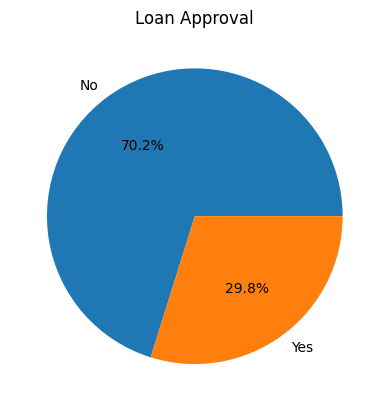

In [440]:
plt.pie(classess_cnt, labels = ["No", "Yes"], autopct = "%1.1f%%")
plt.title("Loan Approval")

### outlier detection

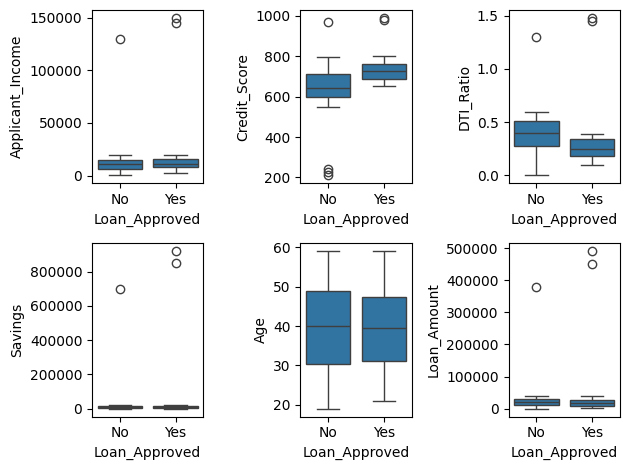

In [441]:
fig, axes = plt.subplots(2, 3)

sns.boxplot(
    ax = axes[0,0], data = df, x = "Loan_Approved", y = "Applicant_Income"
)
sns.boxplot(
    ax = axes[0,1], data = df, x = "Loan_Approved", y = "Credit_Score"
)
sns.boxplot(
    ax = axes[0,2], data = df, x = "Loan_Approved", y = "DTI_Ratio"
)
sns.boxplot(
    ax = axes[1,0], data = df, x = "Loan_Approved", y = "Savings"
)
sns.boxplot(
    ax = axes[1,1], data = df, x = "Loan_Approved", y = "Age"
)
sns.boxplot(
    ax = axes[1,2], data = df, x = "Loan_Approved", y = "Loan_Amount"
)
plt.tight_layout()
# outliers are present in the dataset

In [442]:
df.shape

(1006, 20)

In [443]:
# Compute all iqr_bounds first
iqr_bounds = {}

for col in numerical_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_bounds[col] = (Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

# Apply all conditions together
mask = pd.Series(True, index=df.index)

for col in numerical_col:
    lower, upper = iqr_bounds[col]
    mask &= df[col].between(lower, upper)

df = df[mask].reset_index(drop=True)

In [444]:
df.shape

(1000, 20)

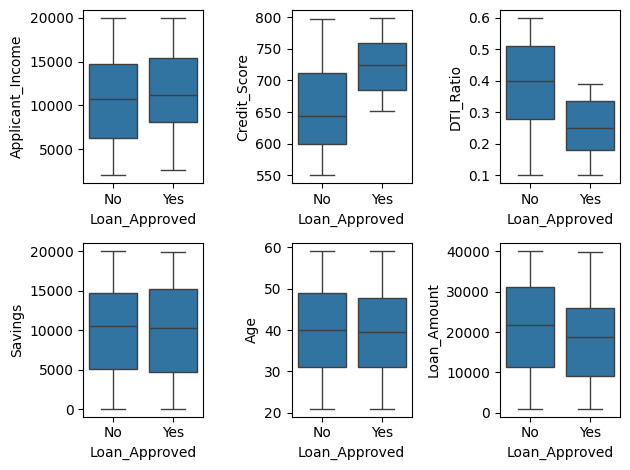

In [445]:
fig, axes = plt.subplots(2, 3)

sns.boxplot(
    ax = axes[0,0], data = df, x = "Loan_Approved", y = "Applicant_Income"
)
sns.boxplot(
    ax = axes[0,1], data = df, x = "Loan_Approved", y = "Credit_Score"
)
sns.boxplot(
    ax = axes[0,2], data = df, x = "Loan_Approved", y = "DTI_Ratio"
)
sns.boxplot(
    ax = axes[1,0], data = df, x = "Loan_Approved", y = "Savings"
)
sns.boxplot(
    ax = axes[1,1], data = df, x = "Loan_Approved", y = "Age"
)
sns.boxplot(
    ax = axes[1,2], data = df, x = "Loan_Approved", y = "Loan_Amount"
)
plt.tight_layout()

# conclusion : NO OUTLIERS

## analyze categories

[Text(0, 0, '422'),
 Text(0, 0, '202'),
 Text(0, 0, '144'),
 Text(0, 0, '135'),
 Text(0, 0, '97')]

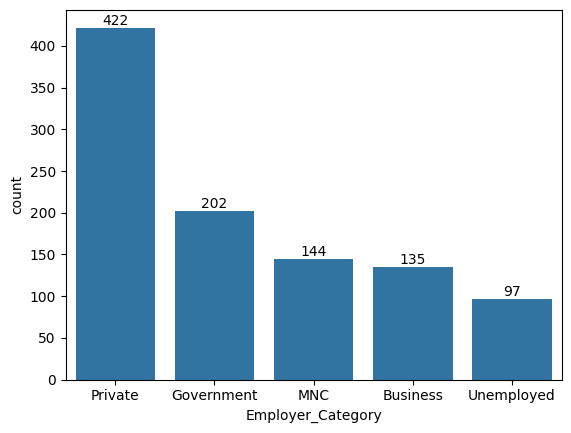

In [446]:
# gender_cnt = df["Gender"].value_counts()
# ax = sns.barplot(gender_cnt)
# ax.bar_label(ax.containers[0])

# edu_cnt = df["Education_Level"].value_counts()
# ax = sns.barplot(edu_cnt)
# ax.bar_label(ax.containers[0])

emp_cnt = df["Employer_Category"].value_counts()
ax = sns.barplot(emp_cnt)
ax.bar_label(ax.containers[0])

[Text(0, 0, '206'), Text(0, 0, '496')]

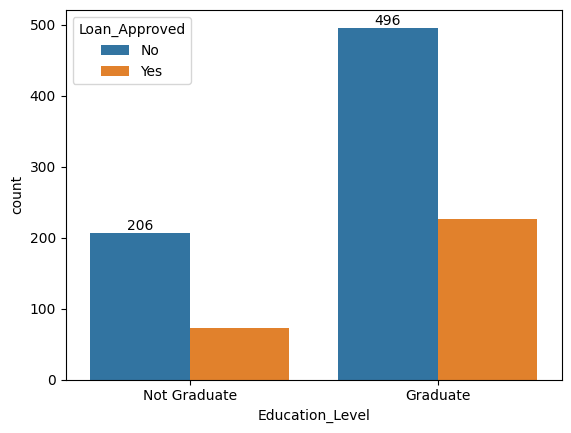

In [447]:
edu_cnt = df["Education_Level"].value_counts()
ax = sns.countplot(data=df, x="Education_Level", hue="Loan_Approved")
ax.bar_label(ax.containers[0])

<Axes: xlabel='Savings', ylabel='Loan_Amount'>

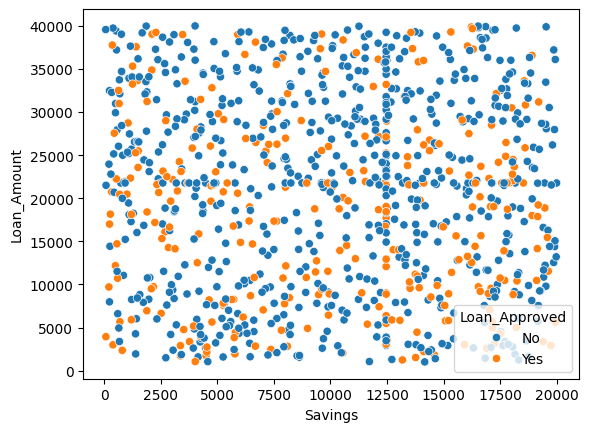

In [448]:
# this doesn't seems help full
sns.scatterplot(data=df, x="Savings", y="Loan_Amount", hue="Loan_Approved")

<Axes: xlabel='Credit_Score', ylabel='Count'>

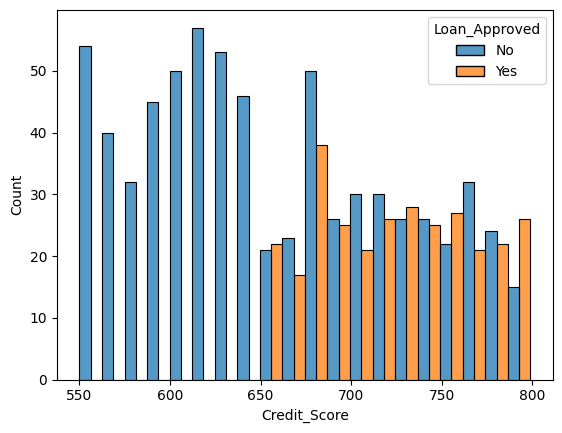

In [449]:
# credit score vs loan approved

sns.histplot(
    data = df,
    x = "Credit_Score",
    bins = 20,
    hue = "Loan_Approved",
    multiple = "dodge"
)

# conclusion : high credit score = loan approval

In [450]:
# removing applicant ID
df.drop(columns=["Applicant_ID"], inplace=True)
df.sample(1)

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
736,2117.0,9873.0,Self-employed,57.0,Married,3.0,652.0,1.0,0.32,16158.0,6107.0,24580.0,48.0,Business,Urban,Graduate,Male,Business,No


## feature engineering

In [451]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# LabelEncoder -> assigns an integer to each category
#    used for ordinal data (order is there like hirearchy where importance differes)

# OneHotEncoder -> creates binary columns for each category(get_dummies)
#    used for nominal data (same importance like gender)

In [452]:
le = LabelEncoder()

df["Education_Level"] = le.fit_transform(df["Education_Level"])
df["Loan_Approved"] = le.fit_transform(df["Loan_Approved"])

In [453]:
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

encoded = ohe.fit_transform(df[cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=ohe.get_feature_names_out(cols),
    index=df.index
)

# ohe.get_feature_names_out(cols)
df = pd.concat(
    [df.drop(columns=cols), encoded_df],
    axis=1
)

## co relation heatmap

In [454]:
nums_cols = df.select_dtypes(include = "number")

corr_matrix = nums_cols.corr()
corr_matrix

nums_cols.corr()["Loan_Approved"].sort_values(ascending = False)

Loan_Approved                      1.000000
Credit_Score                       0.451159
Applicant_Income                   0.119295
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.023001
Coapplicant_Income                 0.003895
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Savings                           -0.012318
Property_Area_Semiurban           -0.012967
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022326
Dependents                        -0.023844
Existing_Loans                    -0.034816
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

<Axes: >

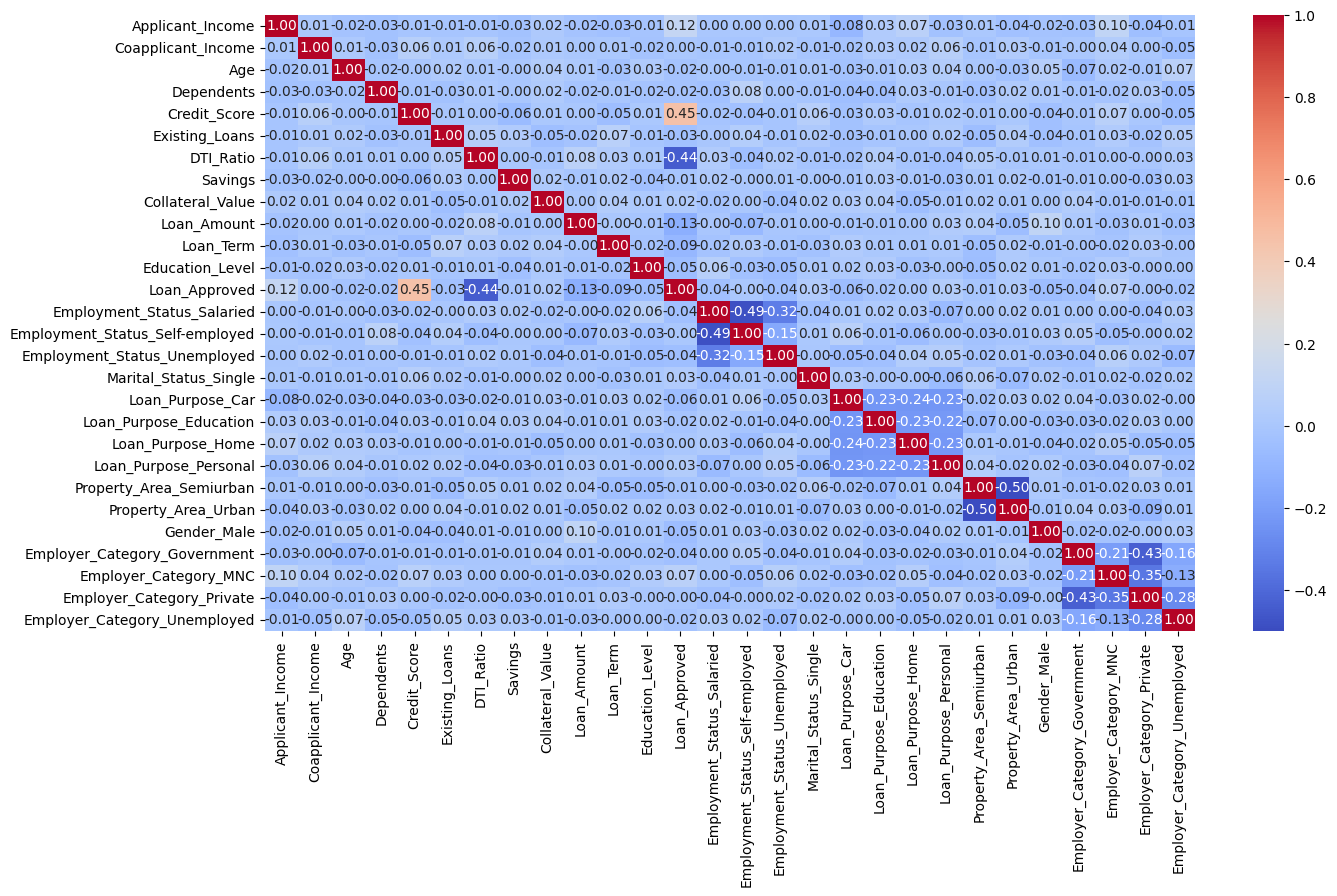

In [455]:
plt.figure(figsize= (15,8))
sns.heatmap(
    corr_matrix,
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)

## TTS + Feature Scaling

In [456]:
x = df.drop(columns = "Loan_Approved")
y = df["Loan_Approved"]

In [457]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.8, random_state = 42
)

In [458]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

## Training & Evaluation of model

In [459]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)
y_pred = log_model.predict(x_test_scaled)

print("Logistic Regression")

# Evaluation
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

Logistic Regression
Precision: 0.7513513513513513
Recall: 0.5673469387755102
F1 score: 0.6465116279069767
Accuracy: 0.81
CM: [[509  46]
 [106 139]]


In [460]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

y_pred = knn_model.predict(x_test_scaled)

# Evaluation
print("KNN Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

KNN Model
Precision: 0.6592592592592592
Recall: 0.363265306122449
F1 score: 0.46842105263157896
Accuracy: 0.7475
CM: [[509  46]
 [156  89]]


In [461]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)

y_pred = nb_model.predict(x_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))


Naive Bayes Model
Precision: 0.8392857142857143
Recall: 0.5755102040816327
F1 score: 0.6828087167070218
Accuracy: 0.83625
CM: [[528  27]
 [104 141]]


## Feature Engineering

In [462]:
# Add or Transform features
df["DTI_Ratio_sq"] = df["DTI_Ratio"] ** 2
df["Credit_Score_sq"] = df["Credit_Score"] ** 2

# df["Applicant_Income_log"] = np.log1p(df["Applicant_Income"])

X = df.drop(columns=["Loan_Approved", "Credit_Score", "DTI_Ratio"])
y = df["Loan_Approved"]

# Train test split
x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


In [463]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

log_model = LogisticRegression()
log_model.fit(x_train_scaled, y_train)
y_pred = log_model.predict(x_test_scaled)

print("Logistic Regression")

# Evaluation
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

Logistic Regression
Precision: 0.7903225806451613
Recall: 0.8032786885245902
F1 score: 0.7967479674796748
Accuracy: 0.875
CM: [[126  13]
 [ 12  49]]


In [464]:
# KNN
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train_scaled, y_train)

y_pred = knn_model.predict(x_test_scaled)

# Evaluation
print("KNN Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))

KNN Model
Precision: 0.6274509803921569
Recall: 0.5245901639344263
F1 score: 0.5714285714285714
Accuracy: 0.76
CM: [[120  19]
 [ 29  32]]


In [465]:
# Naive Bayes
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(x_train_scaled, y_train)

y_pred = nb_model.predict(x_test_scaled)

# Evaluation
print("Naive Bayes Model")
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 score:", f1_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("CM:", confusion_matrix(y_test, y_pred))


Naive Bayes Model
Precision: 0.7833333333333333
Recall: 0.7704918032786885
F1 score: 0.7768595041322314
Accuracy: 0.865
CM: [[126  13]
 [ 14  47]]
